## DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups points based on density, using ε (Epsilon) and MinPts, and can identify noise/outliers.

## K-Means groups points based on their distance from centroids and requires the number of clusters (K) to be specified beforehand.

## Key Difference: K-Means works best with compact, spherical clusters, while DBSCAN can discover irregular/non-linear clusters such as circular rings without knowing the number of clusters in advance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

# Create concentric circular dataset
X, y = make_circles(
    n_samples=1000,
    factor=0.5,
    noise=0.05,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["X1", "X2"]
)

df["True_Label"] = y

print(df.head())

         X1        X2  True_Label
0  0.452592  0.168433           1
1 -0.438027  0.119900           1
2 -0.532224  0.184359           1
3 -0.301402  0.400782           1
4  0.445602 -0.894936           0


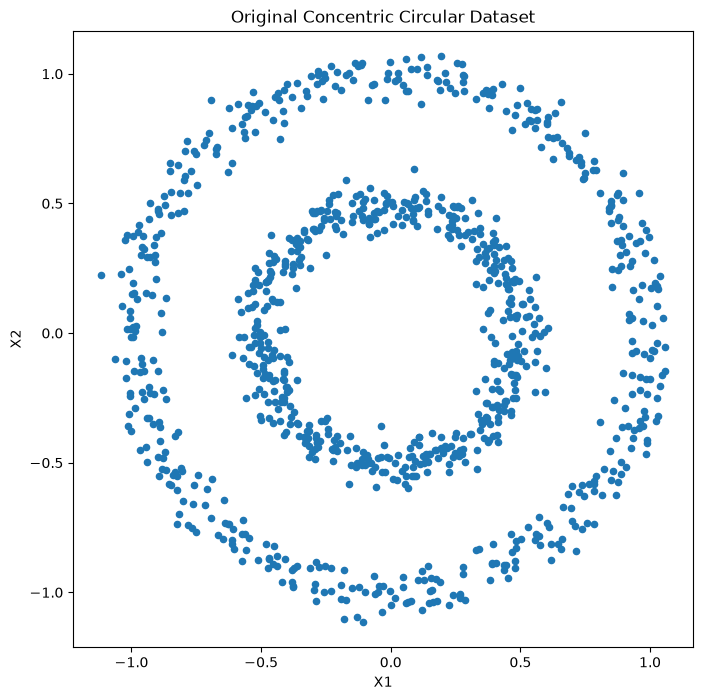

In [2]:
plt.figure(figsize=(8, 8))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=20
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Original Concentric Circular Dataset")

plt.axis("equal")
plt.show()

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

df["KMeans_Cluster"] = kmeans_labels

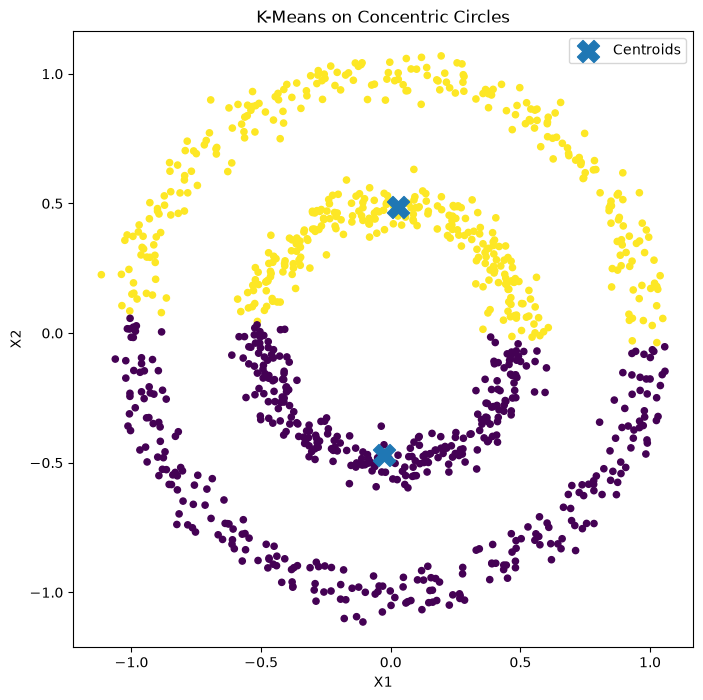

In [4]:
plt.figure(figsize=(8, 8))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans_labels,
    s=20
)

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("K-Means on Concentric Circles")

plt.axis("equal")
plt.legend()
plt.show()

### Epsilon (ε) is the maximum distance around a point that DBSCAN considers its neighborhood.

## "How many other points are within ε distance of me?"

In [5]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.12,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X)

df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN Labels:", np.unique(dbscan_labels))

DBSCAN Labels: [0 1]


## eps = 0.12 → look within a radius of 0.12
## min_samples = 5 → need at least 5 points in that neighborhood to consider it a dense/core region.

In [6]:
n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 2
Number of noise points: 0


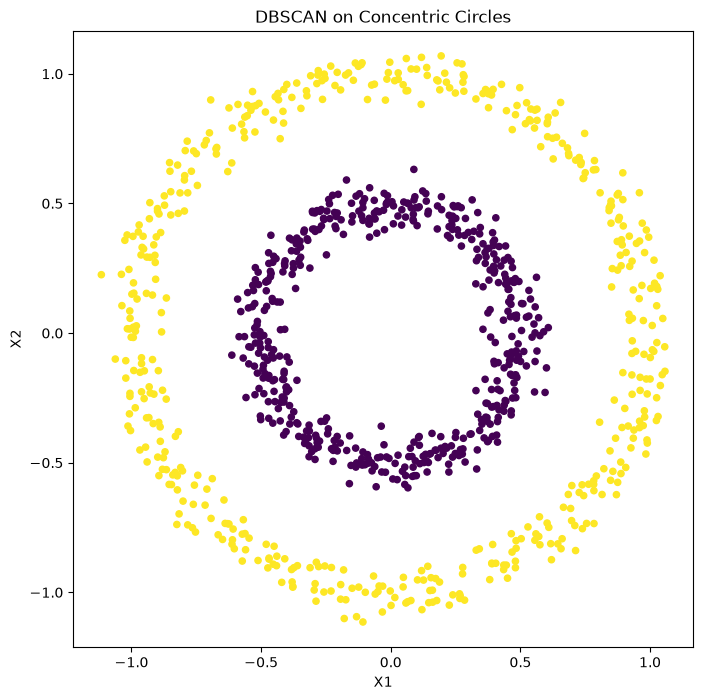

In [7]:
plt.figure(figsize=(8, 8))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=dbscan_labels,
    s=20
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("DBSCAN on Concentric Circles")

plt.axis("equal")
plt.show()

In [8]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# ==============================
# K-MEANS
# ==============================

km_silhouette = silhouette_score(
    X,
    kmeans_labels
)

km_db = davies_bouldin_score(
    X,
    kmeans_labels
)

km_ch = calinski_harabasz_score(
    X,
    kmeans_labels
)


# ==============================
# DBSCAN
# ==============================

# Remove DBSCAN noise
mask = dbscan_labels != -1

X_db = X[mask]
db_labels = dbscan_labels[mask]

db_silhouette = silhouette_score(
    X_db,
    db_labels
)

db_db = davies_bouldin_score(
    X_db,
    db_labels
)

db_ch = calinski_harabasz_score(
    X_db,
    db_labels
)


# ==============================
# RESULTS
# ==============================

print("========== K-MEANS ==========")

print(
    "Silhouette Score:",
    round(km_silhouette, 3)
)

print(
    "Davies-Bouldin Index:",
    round(km_db, 3)
)

print(
    "Calinski-Harabasz Index:",
    round(km_ch, 3)
)


print("\n========== DBSCAN ==========")

print(
    "Silhouette Score:",
    round(db_silhouette, 3)
)

print(
    "Davies-Bouldin Index:",
    round(db_db, 3)
)

print(
    "Calinski-Harabasz Index:",
    round(db_ch, 3)
)

print(
    "Noise Points:",
    n_noise
)

========== K-MEANS ==========
Silhouette Score: 0.354
Davies-Bouldin Index: 1.183
Calinski-Harabasz Index: 577.742

========== DBSCAN ==========
Silhouette Score: 0.112
Davies-Bouldin Index: 894.129
Calinski-Harabasz Index: 0.001
Noise Points: 0


# What is ARI?

## ARI = Adjusted Rand Index

### It measures how similar your predicted clusters are to the actual/ground-truth labels.

#### It is particularly useful when your dataset already has a label column.

In [9]:
from sklearn.metrics import adjusted_rand_score

km_ari = adjusted_rand_score(
    y,
    kmeans_labels
)

db_ari = adjusted_rand_score(
    y,
    dbscan_labels
)

print("\n========== ARI ==========")

print("K-Means ARI:", round(km_ari, 3))
print("DBSCAN ARI:", round(db_ari, 3))


========== ARI ==========
K-Means ARI: -0.001
DBSCAN ARI: 1.0
